<a href="https://colab.research.google.com/github/mohits2508sse-lab/ML-LAB-EXPERIMENT/blob/main/EXP_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Dataset:
     Outlook Temperature Humidity    Wind PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3       Rain        Mild     High    Weak        Yes
4       Rain        Cool   Normal    Weak        Yes
5       Rain        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9       Rain        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13      Rain        Mild     High  Strong         No


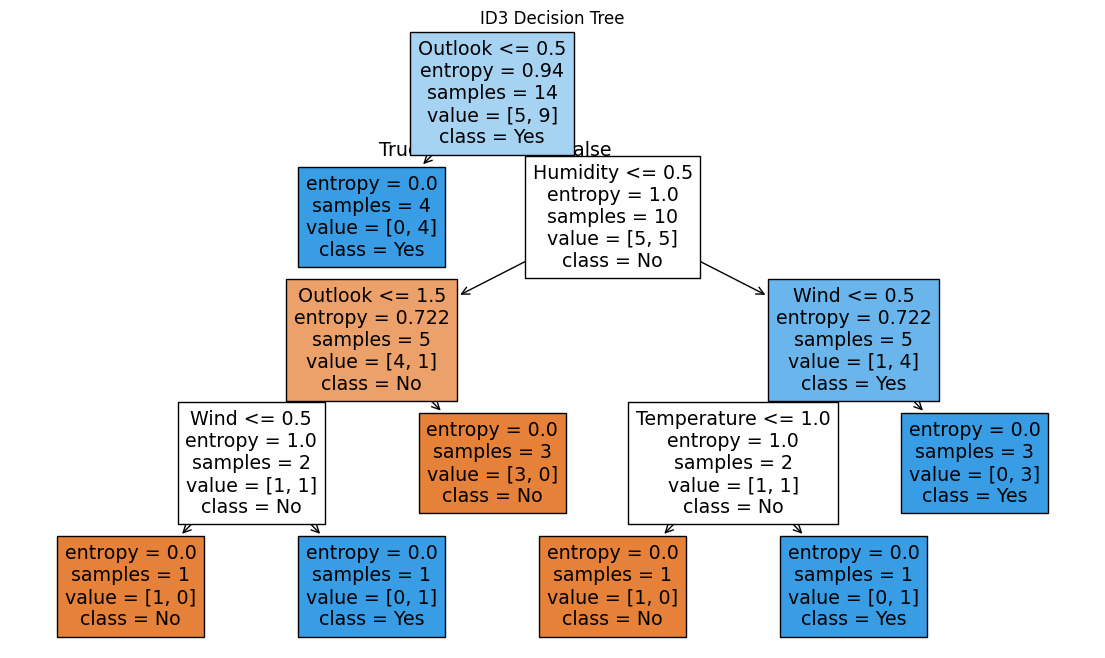


New Sample Classification:
Prediction = No


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
                'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
                    'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal',
                 'High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
             'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes',
                   'No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

print("Training Dataset:")
print(df)

encoders = {}

for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    encoders[column] = le

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

model = DecisionTreeClassifier(criterion='entropy')
model.fit(X, y)

plt.figure(figsize=(14, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=encoders['PlayTennis'].classes_,
    filled=True
)
plt.title("ID3 Decision Tree")
plt.show()

new_sample = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
})

for col in new_sample.columns:
    new_sample[col] = encoders[col].transform(new_sample[col])

prediction = model.predict(new_sample)

result = encoders['PlayTennis'].inverse_transform(prediction)

print("\nNew Sample Classification:")
print("Prediction =", result[0])